In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("AEP_hourly.csv")

df['AEP_MW'] = pd.to_numeric(df['AEP_MW'], errors='coerce')
df = df.dropna()

In [3]:
df['lag1'] = df['AEP_MW'].shift(1)
df = df.dropna()



In [4]:
x = df['lag1'].values
y = df['AEP_MW'].values

In [5]:
split_index = int(len(df) * 0.8)
x_train = x[:split_index]
y_train = y[:split_index]

x_test = x[split_index:]
y_test = y[split_index:]

In [6]:
x_mean, x_std = x_train.mean(), x_train.std()
y_mean, y_std = y_train.mean(), y_train.std()

x_train_norm = (x_train - x_mean)/x_std
y_train_norm = (y_train - y_mean)/y_std

x_test_norm = (x_test - x_mean)/x_std
y_test_norm = (y_test - y_mean)/y_std

In [7]:
def compute_cost(x, y, w, b):
    m = len(x)
    f_wb = w * x + b
    cost = np.sum((f_wb - y) ** 2)/(2*m)
    return cost

In [8]:
def compute_gradient(x, y, w, b):
    m = len(x)
    f_wb = w * x + b
    error = f_wb - y
    dj_dw = np.sum(error * x)/m
    dj_db = np.sum(error)/m
    return dj_dw, dj_db

In [9]:
def gradient_descent(x, y, w_init, b_init, alpha, iterations):
    w = w_init
    b = b_init
    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(x, y, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db
        if i % 100 == 0:
            print(f"Iteration {i}: Cost = {compute_cost(x, y, w, b):.6f}")
    return w, b

In [10]:
w_init, b_init = 0, 0
alpha = 0.01
iterations = 3000

w_final, b_final = gradient_descent(x_train_norm, y_train_norm, w_init, b_init, alpha, iterations)
print("Trained w:", w_final)
print("Trained b:", b_final)

Iteration 0: Cost = 0.490657
Iteration 100: Cost = 0.092153
Iteration 200: Cost = 0.038761
Iteration 300: Cost = 0.031608
Iteration 400: Cost = 0.030649
Iteration 500: Cost = 0.030521
Iteration 600: Cost = 0.030504
Iteration 700: Cost = 0.030501
Iteration 800: Cost = 0.030501
Iteration 900: Cost = 0.030501
Iteration 1000: Cost = 0.030501
Iteration 1100: Cost = 0.030501
Iteration 1200: Cost = 0.030501
Iteration 1300: Cost = 0.030501
Iteration 1400: Cost = 0.030501
Iteration 1500: Cost = 0.030501
Iteration 1600: Cost = 0.030501
Iteration 1700: Cost = 0.030501
Iteration 1800: Cost = 0.030501
Iteration 1900: Cost = 0.030501
Iteration 2000: Cost = 0.030501
Iteration 2100: Cost = 0.030501
Iteration 2200: Cost = 0.030501
Iteration 2300: Cost = 0.030501
Iteration 2400: Cost = 0.030501
Iteration 2500: Cost = 0.030501
Iteration 2600: Cost = 0.030501
Iteration 2700: Cost = 0.030501
Iteration 2800: Cost = 0.030501
Iteration 2900: Cost = 0.030501
Trained w: 0.9690190599430385
Trained b: 3.053231072

In [11]:
def predict_day(day_index):
    x_day = x_test_norm[day_index]
    y_actual = y_test[day_index]
    y_pred_norm = w_final * x_day + b_final
    y_pred_real = y_pred_norm * y_std + y_mean
    return y_actual, y_pred_real

# Example
actual, predicted = predict_day(0)
print("Actual:", actual)
print("Predicted:", predicted)

Actual: 18343.0
Predicted: 18408.233765768975


In [12]:
def predict_next_n_days(n, last_known_value):
    predictions = []
    prev_value_norm = (last_known_value - x_mean)/x_std
    for _ in range(n):
        y_pred_norm = w_final * prev_value_norm + b_final
        y_pred_real = y_pred_norm * y_std + y_mean
        predictions.append(y_pred_real)
        prev_value_norm = (y_pred_real - x_mean)/x_std  # update lag
    return predictions

last_actual = df['AEP_MW'].values[-1]
next_7_days = predict_next_n_days(7, last_actual)

for i, val in enumerate(next_7_days, 1):
    print(f"Day {i}: Predicted Load = {val:.2f}")

Day 1: Predicted Load = 19857.89
Day 2: Predicted Load = 19726.97
Day 3: Predicted Load = 19600.10
Day 4: Predicted Load = 19477.16
Day 5: Predicted Load = 19358.03
Day 6: Predicted Load = 19242.59
Day 7: Predicted Load = 19130.73


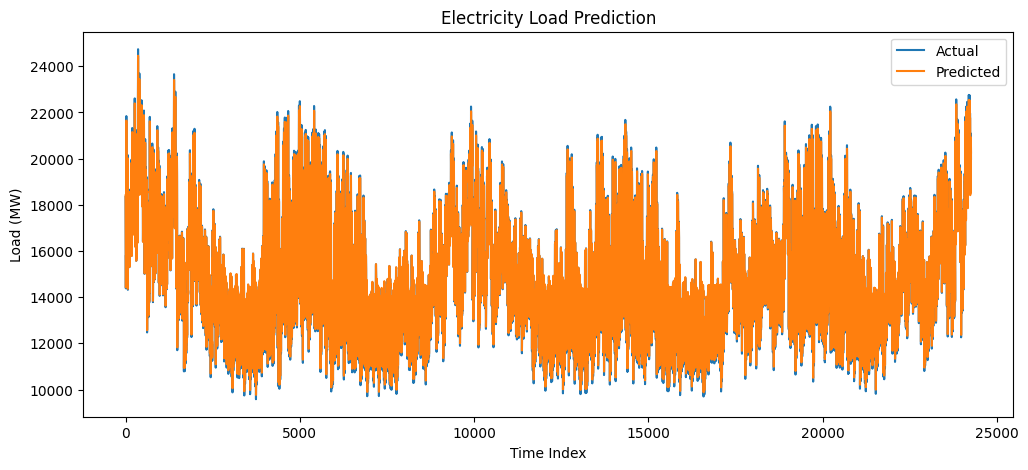

In [13]:
y_test_pred_norm = w_final * x_test_norm + b_final
y_test_pred = y_test_pred_norm * y_std + y_mean

plt.figure(figsize=(12,5))
plt.plot(range(len(y_test)), y_test, label='Actual')
plt.plot(range(len(y_test)), y_test_pred, label='Predicted')
plt.xlabel("Time Index")
plt.ylabel("Load (MW)")
plt.title("Electricity Load Prediction")
plt.legend()
plt.show()